### Cell 1

**Markdown Cell:**

## Phase 1: Dataset Loading & Initial Setup



Importing required libraries and reading `export.csv` to inspect column data types, row counts, and duplicate entries.

**Code Cell:**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df = pd.read_csv('export.csv')
df.info()
print("Duplicates:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8749 entries, 0 to 8748
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tbl                      8749 non-null   object 
 1   Year                     8749 non-null   int64  
 2   quarter                  8749 non-null   int64  
 3   citymarketid             8749 non-null   int64  
 4   city                     8749 non-null   object 
 5   markets                  8749 non-null   int64  
 6   cur_passengers           8749 non-null   object 
 7   cur_fare                 8749 non-null   object 
 8   cur_yield                8749 non-null   float64
 9   distance                 8749 non-null   object 
 10  ly_passengers            8746 non-null   object 
 11  ly_fare                  8746 non-null   object 
 12  ly_yield                 8746 non-null   float64
 13  ly_distance              8746 non-null   object 
 14  Geocoded_City           

---

### Cell 2

**Markdown Cell:**

## 1. Data Cleaning & Attribute Formatting



Dropping exact duplicate rows and removing empty geocoding columns. Numerical columns stored as text due to `$` and `,` formatting are converted into floating-point numbers so mathematical scaling and statistics can be run.

**Code Cell:**

In [3]:
df = df.drop_duplicates()

empty_cols = ['Geocoded_City (address)', 'Geocoded_City (state)', 'Geocoded_City (zip)']
df = df.drop(columns=[c for c in empty_cols if c in df.columns])

clean_cols = ['cur_passengers', 'cur_fare', 'distance', 'ly_passengers', 'ly_fare', 'ly_distance']
for col in clean_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.dtypes

,0
tbl,object
Year,int64
quarter,int64
citymarketid,int64
city,object
markets,int64
cur_passengers,int64
cur_fare,float64
cur_yield,float64
distance,float64


---

### Cell 3

**Markdown Cell:**

## 2. Data Quality Assessment & Missing Data Handling



Identifying attributes with missing values. Median imputation is applied to numerical features (`ly_passengers`, `ly_fare`, `ly_yield`, `ly_distance`) to remain robust against extreme values. Mode imputation is used for missing categorical attributes.

**Code Cell:**

In [4]:
print("Missing before imputation:\n", df.isnull().sum()[df.isnull().sum() > 0])

num_na = ['ly_passengers', 'ly_fare', 'ly_yield', 'ly_distance']
for col in num_na:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

cat_na = ['Geocoded_City', 'Geocoded_City (city)']
for col in cat_na:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Total missing remaining:", df.isnull().sum().sum())

Missing before imputation:
 ly_passengers              3
ly_fare                    3
ly_yield                   3
ly_distance                3
Geocoded_City           2048
Geocoded_City (city)    2305
dtype: int64
Total missing remaining: 0


---

### Cell 4

**Markdown Cell:**

## 3. Data Transformation & Normalization



Applying Min-Max Normalization to scale passenger counts between 0 and 1, Z-score Standardization on fare attributes to set mean = 0 and std = 1, and Decimal Scaling on distance.

**Code Cell:**

In [5]:
df_scaled = df.copy()

minmax = MinMaxScaler()
df_scaled['cur_passengers_minmax'] = minmax.fit_transform(df[['cur_passengers']])

zscore = StandardScaler()
df_scaled['cur_fare_zscore'] = zscore.fit_transform(df[['cur_fare']])

max_dist = df['distance'].abs().max()
j = len(str(int(max_dist)))
df_scaled['distance_decimal_scaled'] = df['distance'] / (10 ** j)

df_scaled[['cur_passengers_minmax', 'cur_fare_zscore', 'distance_decimal_scaled']].head()

,cur_passengers_minmax,cur_fare_zscore,distance_decimal_scaled
0,0.009695,0.979375,0.07613
1,0.002326,0.556598,0.09863
2,0.033257,1.555017,0.10255
3,0.004482,-1.665253,0.09434
4,0.008995,1.210099,0.07509


---

### Cell 5

**Markdown Cell:**

## 4. Discretization, Binning & Export



Converting continuous flight distance values into discrete categories using equal-width binning (Short, Medium, Long haul) and equal-frequency binning (Quartiles). Plots a histogram to inspect feature distribution and exports the cleaned dataset for Phase 2.

**Code Cell:**

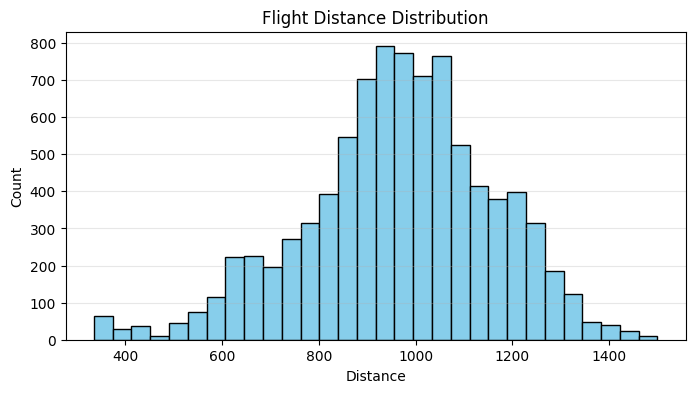

In [6]:
df_scaled['distance_eq_width'] = pd.cut(
    df['distance'],
    bins=3,
    labels=['Short-Haul', 'Medium-Haul', 'Long-Haul']
)

df_scaled['distance_quartiles'] = pd.qcut(
    df['distance'],
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

plt.figure(figsize=(8, 4))
plt.hist(df['distance'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Flight Distance Distribution')
plt.xlabel('Distance')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

df_scaled.to_csv('export_phase1_cleaned.csv', index=False)